# Análisis TMT → K_6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '..')

## 1. Resultados del modelo

In [2]:
df_results = pd.read_csv("../results/regression/2026-01-26_1901/K_6/tmt_k/summary.csv")
df_results[['model', 'r2', 'mae', 'mse']].sort_values('mae')

,model,r2,mae,mse
2,Ridge,0.027146,0.845062,1.110667
0,DummyRegressor,-0.010899,0.848730,1.154102
6,SVR,-0.011006,0.852428,1.154224
7,RandomForestRegressor,0.012825,0.854177,1.127017
3,Lasso,-0.044597,0.869554,1.192574
5,ElasticNet,-0.056747,0.889939,1.206445
4,XGBRegressor,-0.019601,0.891576,1.164037
1,LinearRegression,-0.116319,0.917199,1.274456


## 2. Dataset

In [3]:
from src.model.datasetbuilder.dataset_builder import DatasetBuilder

builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset('tmt_k')

print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Target: {target_name}")


Samples: 185
Features: 170
Target: K_6


## 3. Distribución del target

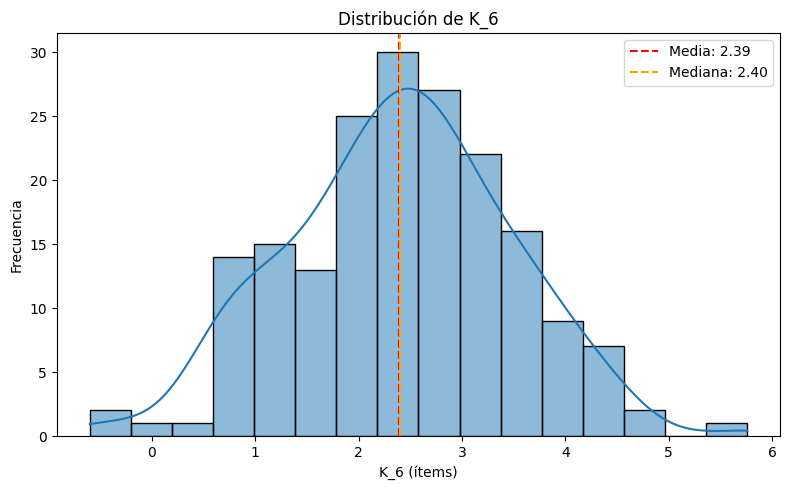

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y, kde=True, ax=ax)
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
ax.axvline(np.median(y), color='orange', linestyle='--', label=f'Mediana: {np.median(y):.2f}')
ax.set_xlabel('K_6 (ítems)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de K_6')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
print(f"Media: {y.mean():.2f}")
print(f"Std: {y.std():.2f}")
print(f"Min: {y.min():.2f}")
print(f"Max: {y.max():.2f}")
print(f"Mediana: {np.median(y):.2f}")

Media: 2.39
Std: 1.07
Min: -0.60
Max: 5.76
Mediana: 2.40


## 4. Resultados del modelo filtrado (tmt_k_v2)

Dataset con filtro: 0 ≤ K_6 ≤ 4.5

In [6]:
# Dataset filtrado
X_v2, y_v2, _, _ = builder.get_dataset('tmt_k_v2')

print(f"Original: {len(y)} sujetos, rango [{y.min():.2f}, {y.max():.2f}]")
print(f"Filtrado: {len(y_v2)} sujetos, rango [{y_v2.min():.2f}, {y_v2.max():.2f}]")
print(f"Sujetos excluidos: {len(y) - len(y_v2)}")

Original: 185 sujetos, rango [-0.60, 5.76]
Filtrado: 180 sujetos, rango [0.00, 4.40]
Sujetos excluidos: 5


In [7]:
df_results_v2 = pd.read_csv("../results/regression/2026-01-28_1905/K_6/tmt_k_v2/summary.csv")
df_results_v2[['model', 'r2', 'mae', 'mse']].sort_values('mae')

,model,r2,mae,mse
1,Ridge,0.020119,0.794551,0.943622
0,DummyRegressor,-0.011204,0.798002,0.973786


## 5. Comparación: Original vs Filtrado

In [8]:
# Comparar R² entre versiones
comparison = pd.merge(
    df_results[['model', 'r2', 'mae']].rename(columns={'r2': 'r2_orig', 'mae': 'mae_orig'}),
    df_results_v2[['model', 'r2', 'mae']].rename(columns={'r2': 'r2_filt', 'mae': 'mae_filt'}),
    on='model'
)
comparison['r2_diff'] = comparison['r2_filt'] - comparison['r2_orig']
comparison['mae_diff'] = comparison['mae_filt'] - comparison['mae_orig']
comparison.sort_values('r2_filt', ascending=False)

,model,r2_orig,mae_orig,r2_filt,mae_filt,r2_diff,mae_diff
1,Ridge,0.027146,0.845062,0.020119,0.794551,-0.007027,-0.050511
0,DummyRegressor,-0.010899,0.848730,-0.011204,0.798002,-0.000305,-0.050728


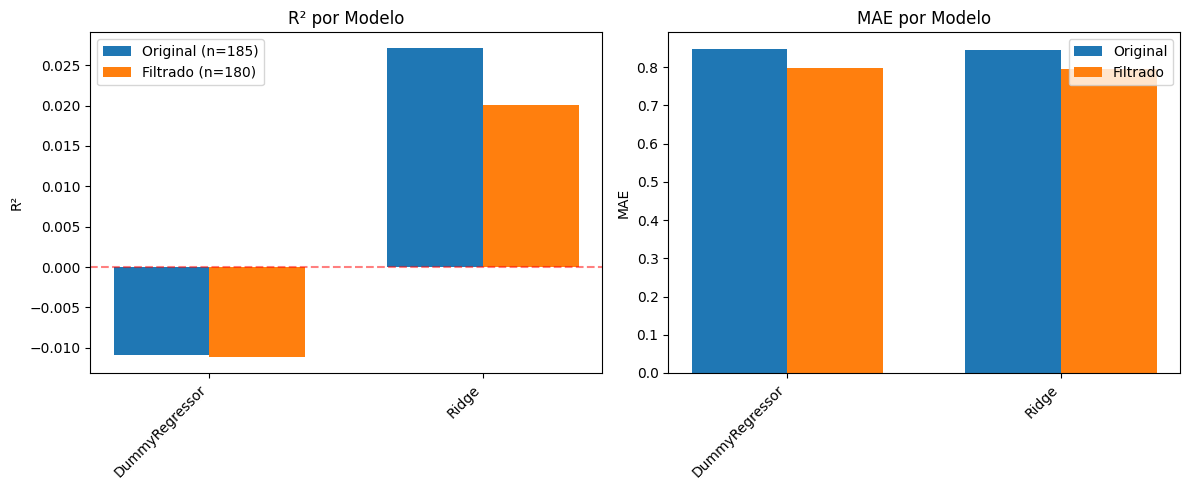

In [9]:
# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² comparison
ax1 = axes[0]
x = range(len(comparison))
width = 0.35
ax1.bar([i - width/2 for i in x], comparison['r2_orig'], width, label='Original (n=185)')
ax1.bar([i + width/2 for i in x], comparison['r2_filt'], width, label='Filtrado (n=180)')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison['model'], rotation=45, ha='right')
ax1.set_ylabel('R²')
ax1.set_title('R² por Modelo')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.legend()

# MAE comparison
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], comparison['mae_orig'], width, label='Original')
ax2.bar([i + width/2 for i in x], comparison['mae_filt'], width, label='Filtrado')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison['model'], rotation=45, ha='right')
ax2.set_ylabel('MAE')
ax2.set_title('MAE por Modelo')
ax2.legend()

plt.tight_layout()
plt.show()